# 05 - Probabilistic Learning (Extension)

## What do losses and regularisation mean as beliefs?

This is an optional extension chapter. The core Workshop 1 arc ends with Notebook 04: data, hypothesis space, optimization space, and generalisation. This notebook reuses the same running problem to give familiar pieces a probabilistic reading.

Use it after Notebook 04 if you want a bridge from least squares and ridge regression to likelihoods, priors, model evidence, MAP estimates, and posterior uncertainty. The examples stay in the same polynomial-regression world so the new ideas attach to behaviour you have already inspected.

A fitted model leaves traces: residuals, unstable extrapolations, coefficients that grow or shrink, and regions where several curves still seem plausible. This notebook starts from those traces and asks what assumptions would make them reasonable.

We will use $\mathcal{D}$ for the observed dataset. A parameter value $\theta\in\Theta$ selects a hypothesis $h_\theta\in\mathcal{H}$. The optimization space $\mathcal{O}$ is the machinery that compares those parameter values or hypotheses: losses, penalties, priors, evidence calculations, optimizers, and summary rules.

In this extension, probabilistic assumptions give pieces of $\mathcal{O}$ a measurement-aware interpretation.

**Concept recap**

| Earlier workshop object | Probabilistic reading in this extension | What to inspect |
|---|---|---|
| Residual loss | Gaussian likelihood under a measurement story | Which residuals are surprising for the chosen $\sigma$? |
| Ridge penalty | Gaussian prior on coefficients or coefficient contrasts | Which functions were plausible before seeing $\mathcal{D}$? |
| Selected ridge solution | MAP estimate: the posterior mode | Which pressure dominates: fit or prior plausibility? |
| Model comparison | Evidence, or prior predictive probability of the data | Did the whole model class make this dataset typical? |
| Uncertainty bands | Posterior predictive summaries conditional on assumptions | Where has finite evidence constrained the function? |

Keep this table nearby as a translation key. The chapter is denser than the core path because it gives familiar selectors a probabilistic interpretation, then labels that interpretation precisely.


## Learning objectives

By the end of this optional extension, you should be able to:

- Translate squared-error residuals into a Gaussian likelihood and say how the noise scale changes residual penalties.
- Explain how a prior changes model selection, parameter fitting, and uncertainty summaries.
- Compare plug-in fit, evidence, MAP, and posterior uncertainty as different summaries from $\mathcal{O}$.
- Inspect whether a probabilistic result is driven mainly by $\mathcal{D}$, $\mathcal{H}$, or a modelling assumption.

## Session arc

1. Start from residuals and name the likelihood they imply.
2. Use Bayes' rule to compare model classes by prior predictive evidence.
3. Vary the prior scale and inspect the induced functions.
4. Repack ridge as MAP, then read posterior uncertainty as conditional on the chosen assumptions.

**Optional extension note:** if the formulas feel dense, keep the learner move simple: predict what an assumption should do, inspect the output, then repack the result in Workshop 1 language.

In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


## From Residuals to a Measurement Story

Begin with something visible. A curve has been fitted, and every training point leaves a residual:

$$
y_i - h_\theta(x_i).
$$

Before naming a probabilistic object, inspect those residuals. Are they small in the units of the measurement? Are they spread evenly across the input range? Would they be surprising if the instrument had standard deviation $\sigma = 0.20$? Would your judgement change for $\sigma = 0.10$ or $\sigma = 0.40$?

Let the observed dataset be

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^n.
$$

**Predict before running:** if the assumed measurement noise is small, which residuals should contribute most to the negative log likelihood? Commit to one region of the plot before inspecting the residual table and visual.

The next cells keep the fitted $\theta$ fixed and ask how plausible the residuals look under candidate measurement stories. The formal likelihood will be named after we have seen what it is measuring.


In [2]:
# Build a dataset, fit a curve, and inspect the residuals.
like_n_samples = 30
like_noise_std = 0.20
assumed_sigma = 0.20
like_seed = 2026
like_degree = 9

x_like, y_like = data.make_regression_data(
    n=like_n_samples,
    noise_std=like_noise_std,
    seed=like_seed,
)
x_like_train, y_like_train, x_like_test, y_like_test = data.train_test_split_for_workshop(
    x_like,
    y_like,
    test_size=0.35,
    seed=like_seed + 1,
)

like_coeffs = models.fit_polynomial_mle(x_like_train, y_like_train, degree=like_degree)
y_like_hat = models.predict_polynomial(x_like_train, like_coeffs)
residuals = y_like_train - y_like_hat

preview_rows = []
for x, y, y_hat, residual in zip(x_like_train[:8], y_like_train[:8], y_like_hat[:8], residuals[:8]):
    preview_rows.append({"x": x, "y": y, "y_hat": y_hat, "residual": residual})

print_rows(preview_rows, digits=4, title="Residuals used by the likelihood")


Residuals used by the likelihood
01. x=0.9051, y=-0.5046, y_hat=-0.5133, residual=0.0088
02. x=0.6359, y=-0.4300, y_hat=-0.5284, residual=0.0984
03. x=0.2263, y=0.8119, y_hat=0.8436, residual=-0.0317
04. x=0.6399, y=-0.6047, y_hat=-0.5632, residual=-0.0415
05. x=0.4477, y=0.4415, y_hat=0.4218, residual=0.0197
06. x=0.8259, y=-0.9465, y_hat=-0.9135, residual=-0.0330
07. x=0.5258, y=0.3504, y_hat=0.2224, residual=0.1280
08. x=0.2779, y=1.1216, y_hat=1.0724, residual=0.0492


In [3]:
# Convert residuals into a Gaussian negative log likelihood.
quadratic_term = 0.5 * np.sum((residuals / assumed_sigma) ** 2)
normalisation_term = 0.5 * len(y_like_train) * np.log(2.0 * np.pi * assumed_sigma**2)
nll_manual = quadratic_term + normalisation_term
nll_helper = metrics.gaussian_negative_log_likelihood(y_like_train, y_like_hat, sigma=assumed_sigma)

print_rows(
    [
        {"quantity": "quadratic_residual_term", "value": quadratic_term},
        {"quantity": "gaussian_normalisation_term", "value": normalisation_term},
        {"quantity": "manual_nll", "value": nll_manual},
        {"quantity": "helper_nll", "value": nll_helper},
    ],
    digits=4,
    title="Negative log likelihood components",
)


Negative log likelihood components
01. quantity=quadratic_residual_term, value=7.0709
02. quantity=gaussian_normalisation_term, value=-13.8100
03. quantity=manual_nll, value=-6.7390
04. quantity=helper_nll, value=-6.7390


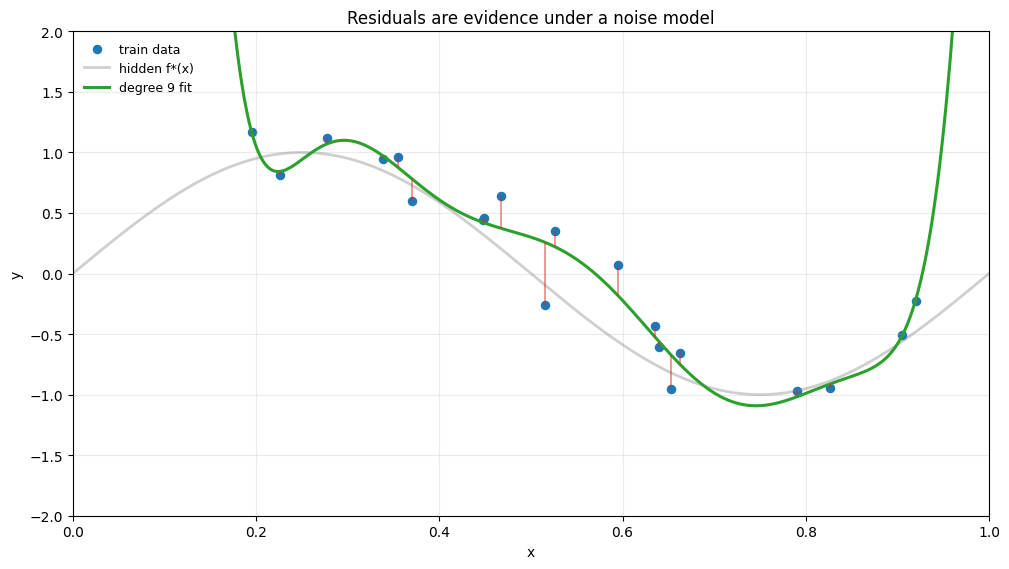

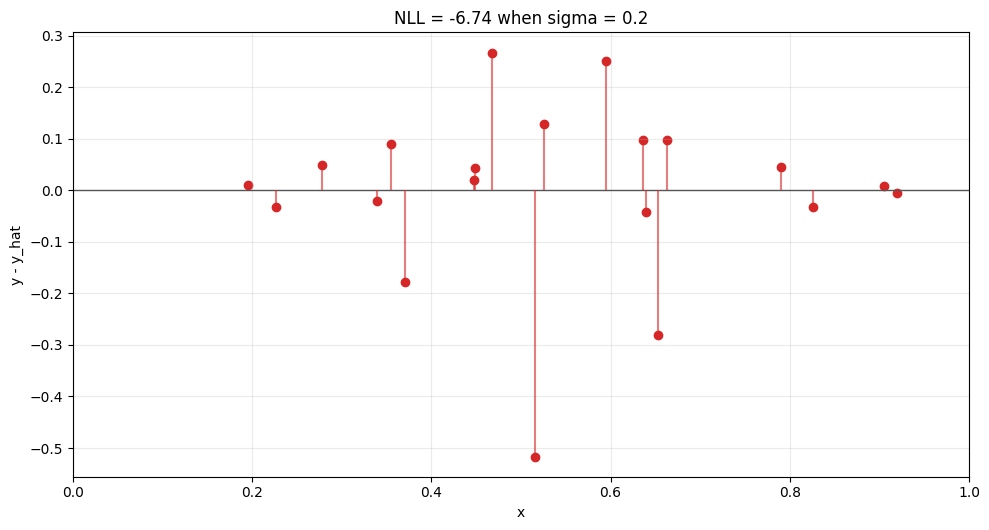

In [4]:
# Visualise the residuals that drive the likelihood.
x_grid = data.make_test_grid(n_points=500)
y_like_curve = models.predict_polynomial(x_grid, like_coeffs)

fig_curve, ax_curve = plt.subplots(figsize=(10.2, 5.8))
ax_curve.scatter(x_like_train, y_like_train, s=34, color="#1f77b4", label="train data")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax_curve.plot(x_grid, y_like_curve, color="#2ca02c", linewidth=2.2, label=f"degree {like_degree} fit")
for x_value, y_value, y_hat in zip(x_like_train, y_like_train, y_like_hat):
    ax_curve.vlines(x_value, y_hat, y_value, color="#d62728", alpha=0.6, linewidth=1.1)
ax_curve.set_title("Residuals are evidence under a noise model")
ax_curve.set_xlabel("x")
ax_curve.set_ylabel("y")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.0, 2.0)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=9)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_resid, ax_resid = plt.subplots(figsize=(10.0, 5.4))
ax_resid.axhline(0.0, color="#555555", linewidth=1.0)
ax_resid.scatter(x_like_train, residuals, s=36, color="#d62728")
ax_resid.vlines(x_like_train, 0.0, residuals, color="#d62728", alpha=0.6)
ax_resid.set_title(f"NLL = {nll_manual:.2f} when sigma = {assumed_sigma}")
ax_resid.set_xlabel("x")
ax_resid.set_ylabel("y - y_hat")
ax_resid.set_xlim(0.0, 1.0)
ax_resid.grid(alpha=0.25)
fig_resid.tight_layout()
show_fig(fig_resid)


**Inspect and repack**

- Inspect: match the largest visible residuals to the residual story behind the negative log likelihood. Which points would feel less surprising if `assumed_sigma` were larger?
- Repack: describe this loss as a measurement claim, not only as a number to minimise.

**Name the quantity**

The measurement story above is one ingredient we can use to build the optimization space $\mathcal{O}$. If it says that each observation is generated by adding independent Gaussian noise to the curve,

$$
y_i = h_\theta(x_i) + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}(0,\sigma^2),
$$

then the compatibility of one observation with the proposed curve is

$$
p(y_i \mid x_i,\theta,\sigma) = \mathcal{N}(y_i;h_\theta(x_i),\sigma^2).
$$

For the dataset, treating the observed inputs as fixed,

$$
p(\mathcal{D}\mid\theta,\sigma) = \prod_i p(y_i\mid x_i,\theta,\sigma).
$$

This conditional density is the **likelihood**. It reads forward: if this $\theta$ and measurement story were true, how compatible would the observed $\mathcal{D}$ be?

Taking negative logs gives

$$
-\log p(\mathcal{D}\mid\theta,\sigma)
= \frac{1}{2\sigma^2}\sum_i (y_i-h_\theta(x_i))^2 + \frac{n}{2}\log(2\pi\sigma^2).
$$

When $\sigma$ is fixed, the $\theta$ that minimises squared error also maximises this Gaussian likelihood. In workshop-frame language, $\mathcal{H}$ and $\mathcal{D}$ stayed fixed; we changed how $\mathcal{O}$ interprets residuals.

Discuss this: if the instrument became more precise, which residuals would start to demand a different explanation?


## Bayes' Rule: Updating Belief After the Residual Story

A likelihood scores $p(\mathcal{D}\mid\theta)$: compatibility of the data with a proposed parameter value under a chosen measurement story. Bayesian reasoning asks for the reverse quantity after combining that compatibility with prior belief.

For parameters,

$$
p(\theta\mid\mathcal{D})
= \frac{p(\mathcal{D}\mid\theta)p(\theta)}{p(\mathcal{D})}.
$$

Often the useful working form is

$$
p(\theta\mid\mathcal{D}) \propto p(\mathcal{D}\mid\theta)p(\theta).
$$

The denominator is the normalising constant that makes the posterior integrate to one:

$$
p(\mathcal{D})=\int p(\mathcal{D}\mid\theta)p(\theta)\,d\theta.
$$

For model classes such as polynomial degree $M_d$, the same update has the form

$$
p(M_d\mid\mathcal{D})
\propto p(M_d)p(\mathcal{D}\mid M_d).
$$

The posterior, MAP estimate, and model evidence can then become different ways for the optimization space $\mathcal{O}$ to select or summarise hypotheses. The next example keeps the update visible: prior plausibility times evidence from the data, then normalise.


## Comparing Model Classes by Their Prior Predictive Story

Look at several polynomial degrees. A best fitted curve tells us what each class can do after choosing favourable parameters. Bayesian model comparison asks a broader question: before choosing $\theta$, how much probability did the whole model class assign to datasets like $\mathcal{D}$?

**Extension depth:** the next calculation is mathematically denser than the core notebooks. Its role is not to make evidence a required workshop tool; it is to show how model comparison changes when the selector averages over parameter values instead of only scoring the best one.

**Assumptions ledger before evidence**

| Assumption | Meaning in this toy world | Why it matters |
|---|---|---|
| Fixed observed inputs | The $x_i$ values are conditioned on, not modelled | Evidence scores $y_{1:n}$ given these inputs |
| Gaussian observation noise | $y_i=h_\theta(x_i)+\epsilon_i$, with independent $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$ | Defines the likelihood and the residual scale |
| Proper Gaussian parameter prior | $\theta\mid M_d\sim\mathcal{N}(0,\tau^2I)$ | Evidence needs probability mass before seeing data |
| Chosen degree set | Only the listed polynomial degrees compete | Posterior model probabilities are conditional on this menu |
| Model prior | `bayes_model_prior` assigns initial plausibility to each degree | Posterior model probabilities combine prior and evidence |

For a model class $M_d$ with degree $d$, suppose the observed inputs $x_{1:n}$, noise scale $\sigma$, and prior scale $\tau$ are fixed, and

$$
\theta \mid M_d \sim \mathcal{N}(0,\Sigma_0), \qquad \Sigma_0=\tau^2 I.
$$

The evidence for the model class averages the likelihood over the parameter values that the prior considered plausible:

$$
p(\mathcal{D}\mid M_d)
= \int p(\mathcal{D}\mid\theta,M_d)p(\theta\mid M_d)\,d\theta.
$$

For a linear-Gaussian model this integral has a closed form. With feature matrix $\Phi_d=\Phi_d(x_{1:n})$,

$$
y_{1:n}\mid x_{1:n},M_d,\sigma,\tau
\sim \mathcal{N}(0,\sigma^2 I + \Phi_d\Sigma_0\Phi_d^\top).
$$

**Predict before running:** which degree do you expect to win under evidence: the most flexible degree, the smoothest degree, or the degree whose prior predictive story makes this dataset least surprising? Write down a prediction before reading the posterior bar chart.

The table below shows the update in two views. The columns `relative_evidence` and `prior_x_relative_evidence` expose the conceptual multiplication before normalisation. The log columns are the numerically stable way to compute the same update.

A proper prior is important for this comparison because the model class must say how its probability mass is distributed before seeing $\mathcal{D}$. Change `bayes_model_prior`, `bayes_sigma`, or `bayes_tau` and rerun the evidence and plotting cells below to see how the posterior preferences move.


In [5]:
# Compare model classes with prior x marginal likelihood -> posterior.
def log_marginal_likelihood_components(Phi, y, sigma, prior_cov):
    covariance = sigma**2 * np.eye(len(y)) + Phi @ prior_cov @ Phi.T
    sign, logdet = np.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("covariance must be positive definite")
    alpha = np.linalg.solve(covariance, y)
    quadratic = float(y @ alpha)
    normalizer = float(len(y) * np.log(2.0 * np.pi))
    log_evidence = -0.5 * (quadratic + logdet + normalizer)
    return log_evidence, quadratic, float(logdet), normalizer

bayes_degrees = (1, 3, 9, 15)
bayes_model_prior = np.array([0.25, 0.35, 0.30, 0.10])
bayes_sigma = 0.20
bayes_tau = 1.00

if not np.isclose(np.sum(bayes_model_prior), 1.0):
    raise ValueError("bayes_model_prior should sum to 1")

x_bayes, y_bayes = data.make_regression_data(n=22, noise_std=0.20, seed=2026)

bayes_rows = []
log_evidences = []
bayes_coeffs = {}
for degree, prior_prob in zip(bayes_degrees, bayes_model_prior):
    Phi = models.polynomial_features(x_bayes, degree=degree)
    prior_cov = bayes_tau**2 * np.eye(degree + 1)
    coeffs = models.fit_polynomial_mle(x_bayes, y_bayes, degree=degree)
    train_pred = models.predict_polynomial(x_bayes, coeffs)
    plug_in_log_likelihood = -metrics.gaussian_negative_log_likelihood(y_bayes, train_pred, sigma=bayes_sigma)
    log_evidence, evidence_quadratic, evidence_logdet, evidence_normalizer = log_marginal_likelihood_components(
        Phi, y_bayes, sigma=bayes_sigma, prior_cov=prior_cov
    )
    log_evidences.append(log_evidence)
    bayes_coeffs[degree] = coeffs
    bayes_rows.append(
        {
            "hypothesis": f"degree_{degree}",
            "prior_p_M": prior_prob,
            "plug_in_log_likelihood": plug_in_log_likelihood,
            "evidence_quadratic": evidence_quadratic,
            "evidence_logdet": evidence_logdet,
            "log_evidence": log_evidence,
        }
    )

log_evidences = np.array(log_evidences)
relative_evidence = np.exp(log_evidences - np.max(log_evidences))
posterior_unnormalised = bayes_model_prior * relative_evidence
bayes_posterior = posterior_unnormalised / np.sum(posterior_unnormalised)
log_joints = np.log(bayes_model_prior) + log_evidences

for row, rel_ev, update_weight, log_joint, posterior_prob in zip(
    bayes_rows,
    relative_evidence,
    posterior_unnormalised,
    log_joints,
    bayes_posterior,
):
    row["relative_evidence"] = rel_ev
    row["prior_x_relative_evidence"] = update_weight
    row["log_joint"] = log_joint
    row["posterior_p_M_given_D"] = posterior_prob

print_rows(bayes_rows, digits=5, title="Prior x evidence update over candidate degrees")

Prior x evidence update over candidate degrees
01. hypothesis=degree_1, prior_p_M=0.25000, plug_in_log_likelihood=-33.23013, evidence_quadratic=105.60673, evidence_logdet=-60.98557, log_evidence=-42.52723, relative_evidence=4.11e-13, prior_x_relative_evidence=1.03e-13, log_joint=-43.91352, posterior_p_M_given_D=3.04e-13
02. hypothesis=degree_3, prior_p_M=0.35000, plug_in_log_likelihood=6.36808, evidence_quadratic=88.60961, evidence_logdet=-58.62452, log_evidence=-35.20919, relative_evidence=6.19e-10, prior_x_relative_evidence=2.17e-10, log_joint=-36.25902, posterior_p_M_given_D=6.41e-10
03. hypothesis=degree_9, prior_p_M=0.30000, plug_in_log_likelihood=9.13598, evidence_quadratic=43.67926, evidence_logdet=-55.63868, log_evidence=-14.23693, relative_evidence=0.79379, prior_x_relative_evidence=0.23814, log_joint=-15.44091, posterior_p_M_given_D=0.70426
04. hypothesis=degree_15, prior_p_M=0.10000, plug_in_log_likelihood=9.81286, evidence_quadratic=41.82479, evidence_logdet=-54.24609, log_

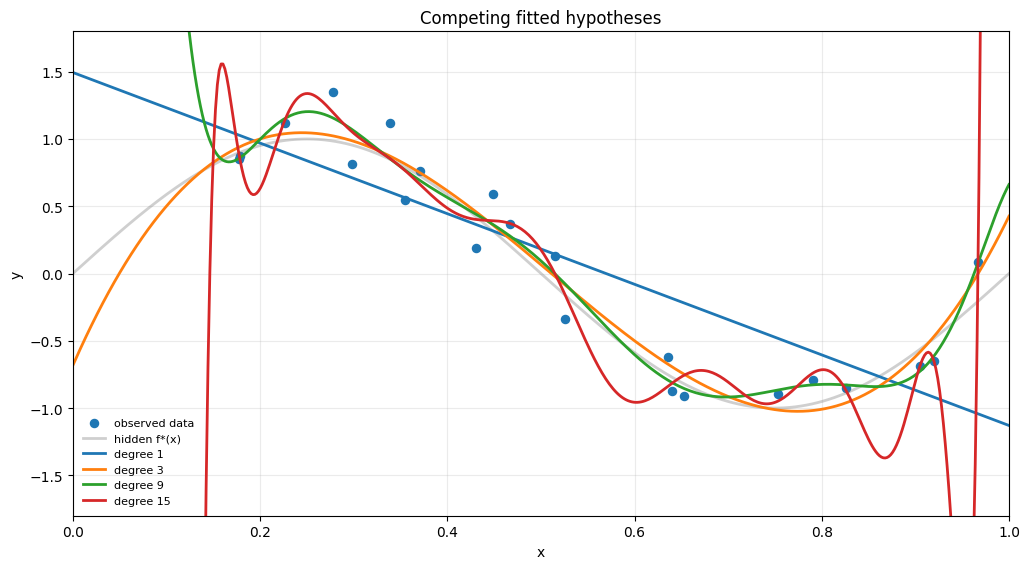

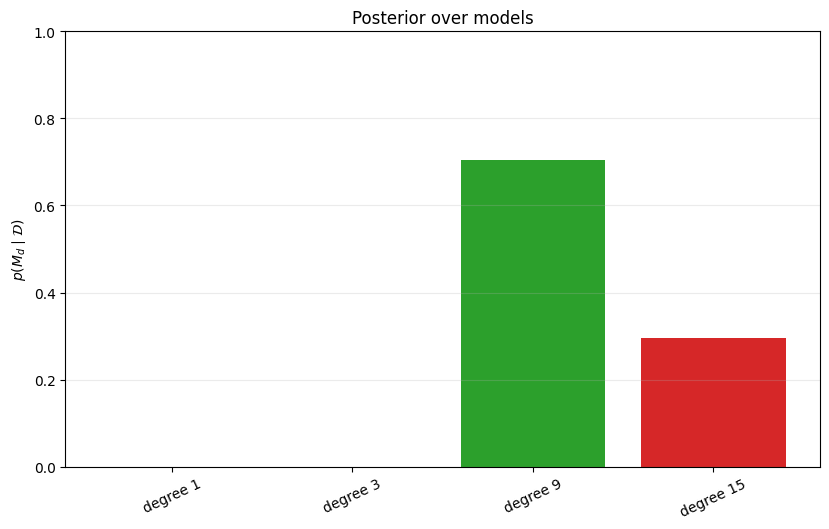

In [6]:
# Plot the candidate hypotheses and the posterior preference over them.
x_grid = data.make_test_grid(n_points=500)
colors = plt.get_cmap("tab10")

fig_curves, ax_curves = plt.subplots(figsize=(10.4, 5.8))
ax_curves.scatter(x_bayes, y_bayes, s=34, color="#1f77b4", label="observed data")
ax_curves.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
for idx, degree in enumerate(bayes_degrees):
    ax_curves.plot(
        x_grid,
        models.predict_polynomial(x_grid, bayes_coeffs[degree]),
        linewidth=2.0,
        color=colors(idx),
        label=f"degree {degree}",
    )
ax_curves.set_title("Competing fitted hypotheses")
ax_curves.set_xlabel("x")
ax_curves.set_ylabel("y")
ax_curves.set_xlim(0.0, 1.0)
ax_curves.set_ylim(-1.8, 1.8)
ax_curves.grid(alpha=0.25)
ax_curves.legend(frameon=False, fontsize=8)
fig_curves.tight_layout()
show_fig(fig_curves)

labels = [f"degree {degree}" for degree in bayes_degrees]
bar_colors = [colors(idx) for idx, _ in enumerate(bayes_degrees)]
fig_post, ax_post = plt.subplots(figsize=(8.4, 5.4))
ax_post.bar(labels, bayes_posterior, color=bar_colors)
ax_post.set_title("Posterior over models")
ax_post.set_ylabel(r"$p(M_d \mid \mathcal{D})$")
ax_post.set_ylim(0.0, 1.0)
ax_post.tick_params(axis="x", rotation=25)
ax_post.grid(axis="y", alpha=0.25)
fig_post.tight_layout()
show_fig(fig_post)


**Inspect and repack**

- Inspect: compare the fitted curves with the posterior bar chart. Which degree looks visually flexible, and which degree receives the most posterior probability?
- Repack: explain the posterior preference as prior plausibility times prior predictive evidence, not just as lowest training error.

**Diagnose**

Read the table from left to right. The prior gives each degree an initial share of plausibility. The evidence asks how much probability that degree assigned to datasets like $\mathcal{D}$ after averaging over its prior for $\theta$. Multiplying those two quantities and normalising gives the posterior over degrees.

The `plug_in_log_likelihood` column is a useful contrast: it scores the curve after the best-fitting $\theta$ has been chosen. The evidence columns ask how plausible the model class was before that choice. `evidence_quadratic` reflects data fit under the prior predictive covariance, while `evidence_logdet` reflects the volume of outcomes the model class spread probability over.

Reflection prompts:

- Which degree had the best fitted curve, and did it also receive the strongest evidence?
- Where did the prior over model classes matter most?
- What would you expect to happen if the observation story used a larger $\sigma$?

## Evidence Depends on Prior Scale

The prior scale $\tau$ controls how widely a model class spreads probability mass over functions before seeing the data. That makes evidence sensitive to a modelling judgement, not just to curve flexibility.

**Predict before running:** for very small $\tau$, which degrees should be too constrained to explain the data? For very large $\tau$, which degrees should spread probability over too many extreme datasets? Choose one `tau` value you expect to favour each degree, then compare with the table.

Read the next table as a stress test of the prior story. Very small $\tau$ says most plausible functions are tightly constrained. Very large $\tau$ says extreme functions were also plausible. Which scale makes the observed $\mathcal{D}$ look most typical for each degree?


In [7]:
# Sweep the prior scale to see how evidence changes.
tau_values = (0.10, 0.30, 1.00, 3.00)
tau_rows = []

for tau_value in tau_values:
    evidence_by_degree = []
    for degree in bayes_degrees:
        Phi = models.polynomial_features(x_bayes, degree=degree)
        prior_cov = tau_value**2 * np.eye(degree + 1)
        log_evidence, _, _, _ = log_marginal_likelihood_components(
            Phi, y_bayes, sigma=bayes_sigma, prior_cov=prior_cov
        )
        evidence_by_degree.append(log_evidence)
        tau_rows.append(
            {
                "tau": tau_value,
                "degree": degree,
                "log_evidence": log_evidence,
            }
        )
    best_degree = bayes_degrees[int(np.argmax(evidence_by_degree))]
    tau_rows.append({"tau": tau_value, "degree": "best", "log_evidence": f"degree {best_degree}"})

print_rows(tau_rows, digits=4, title="Evidence sensitivity to the prior scale")

Evidence sensitivity to the prior scale
01. tau=0.1000, degree=1, log_evidence=-125.6212
02. tau=0.1000, degree=3, log_evidence=-106.9574
03. tau=0.1000, degree=9, log_evidence=-104.4349
04. tau=0.1000, degree=15, log_evidence=-103.6648
05. tau=0.1000, degree=best, log_evidence=degree 15
06. tau=0.3000, degree=1, log_evidence=-70.9747
07. tau=0.3000, degree=3, log_evidence=-63.4474
08. tau=0.3000, degree=9, log_evidence=-51.2585
09. tau=0.3000, degree=15, log_evidence=-44.6726
10. tau=0.3000, degree=best, log_evidence=degree 15
11. tau=1.0000, degree=1, log_evidence=-42.5272
12. tau=1.0000, degree=3, log_evidence=-35.2092
13. tau=1.0000, degree=9, log_evidence=-14.2369
14. tau=1.0000, degree=15, log_evidence=-14.0060
15. tau=1.0000, degree=best, log_evidence=degree 15
16. tau=3.0000, degree=1, log_evidence=-40.8283
17. tau=3.0000, degree=3, log_evidence=-23.4166
18. tau=3.0000, degree=9, log_evidence=-10.9905
19. tau=3.0000, degree=15, log_evidence=-12.0117
20. tau=3.0000, degree=best,

**Inspect and repack**

- Inspect: for each `tau`, mark the degree with the largest log evidence. Does changing the prior scale mostly shift scores, change the ranking, or both?
- Repack: describe `tau` as a claim about which functions were plausible before seeing $\mathcal{D}$.

## Priors as Preferences Over Functions

The prior was written over $\theta$, but we usually reason about curves. Sampling from the prior is a quick way to see what the model class believed before seeing $\mathcal{D}$.

For the model-evidence example above, we used a proper Gaussian prior on all parameters:

$$
\theta \sim \mathcal{N}(0,\tau^2 I).
$$

Small $\tau$ keeps most coefficients near zero. Large $\tau$ permits larger coefficients. In polynomial regression, that can mean rapidly changing functions, especially near the edges of the input range.

**Predict before running:** before looking at the prior samples, decide which panel should assign more prior probability to wild edge behaviour. Then use the observed-$x$ rug marks to ask whether that behaviour is constrained by data or only by the prior.

The induced function prior has covariance

$$
\operatorname{cov}(f(x),f(x')) = \phi(x)^\top\Sigma_0\phi(x').
$$

When $\Sigma_0=\tau^2I$,

$$
\operatorname{cov}(f(x),f(x')) = \tau^2\phi(x)^\top\phi(x').
$$

This covariance depends on the feature map and scaling. Raw monomials, centred polynomials, orthogonal features, and Fourier features would all imply different beliefs about functions even with the same numerical $\tau$.

Notebook 03 used a ridge/MAP convention where the intercept was left unpenalised and the remaining parameters had Gaussian priors. That convention is useful for fitting; model evidence needs a proper prior or an explicit limiting argument.


In [8]:
# Sample theta values from two priors and look at the induced functions.
prior_degree = 9
small_tau = 0.20
large_tau = 1.50
n_prior_samples = 10
prior_seed = 18

rng = np.random.default_rng(prior_seed)
x_prior_grid = data.make_test_grid(n_points=500)
small_coeff_samples = rng.normal(scale=small_tau, size=(n_prior_samples, prior_degree + 1))
large_coeff_samples = rng.normal(scale=large_tau, size=(n_prior_samples, prior_degree + 1))

print_rows(
    [
        {"prior": "small_tau", "tau": small_tau, "first_sample_norm": np.linalg.norm(small_coeff_samples[0])},
        {"prior": "large_tau", "tau": large_tau, "first_sample_norm": np.linalg.norm(large_coeff_samples[0])},
    ],
    digits=4,
    title="Prior scales before seeing data",
)


Prior scales before seeing data
01. prior=small_tau, tau=0.2000, first_sample_norm=0.8749
02. prior=large_tau, tau=1.5000, first_sample_norm=2.8337


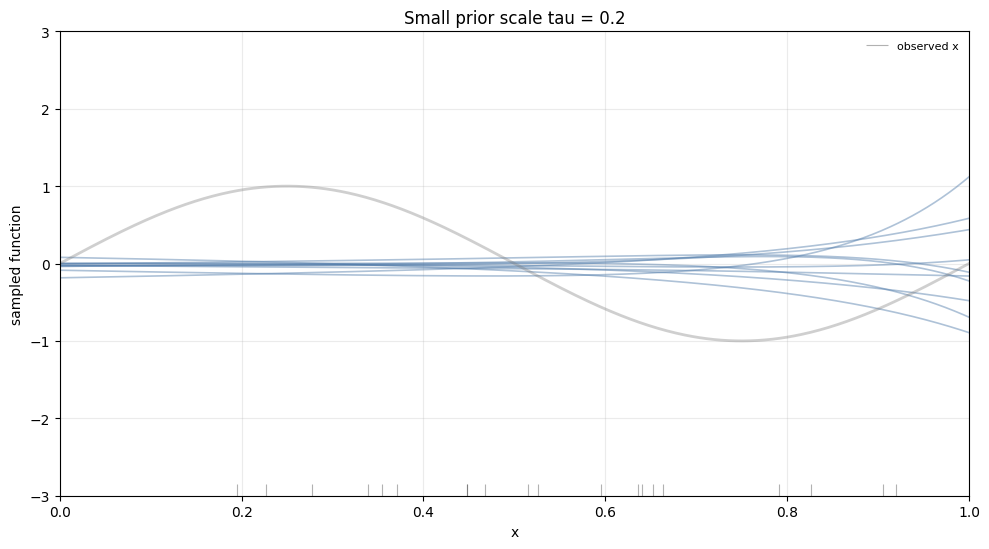

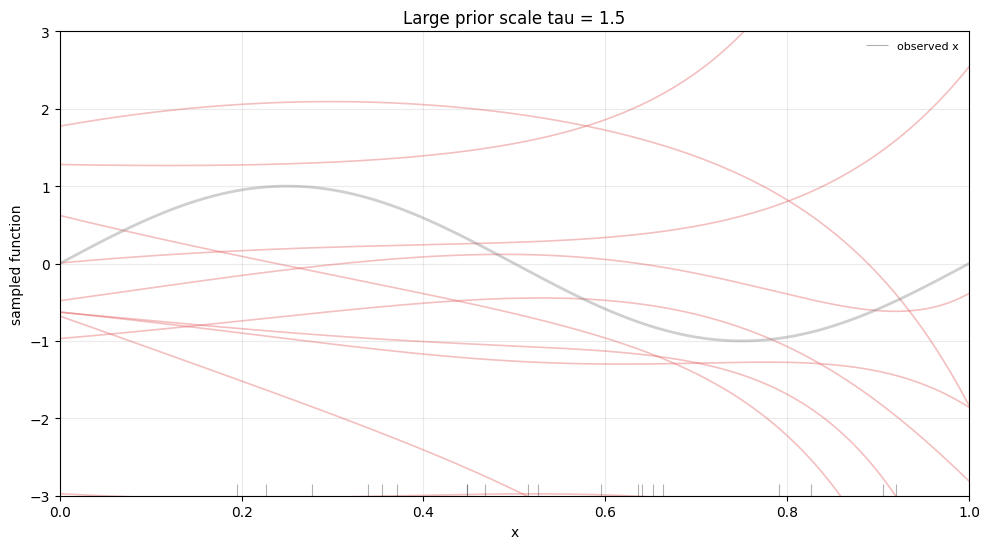

In [9]:
# Visualise the functions implied by those sampled theta values.
prior_views = [
    (f"Small prior scale tau = {small_tau}", small_coeff_samples, "#4c78a8", 0.45),
    (f"Large prior scale tau = {large_tau}", large_coeff_samples, "#e15759", 0.38),
]

for title, coeff_samples, color, alpha in prior_views:
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    for coeffs in coeff_samples:
        ax.plot(x_prior_grid, models.predict_polynomial(x_prior_grid, coeffs), color=color, alpha=alpha, linewidth=1.2)
    ax.plot(x_prior_grid, data.true_function(x_prior_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.vlines(x_like_train, -3.0, -2.85, color="#222222", alpha=0.35, linewidth=0.8, label="observed x")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("sampled function")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-3.0, 3.0)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)


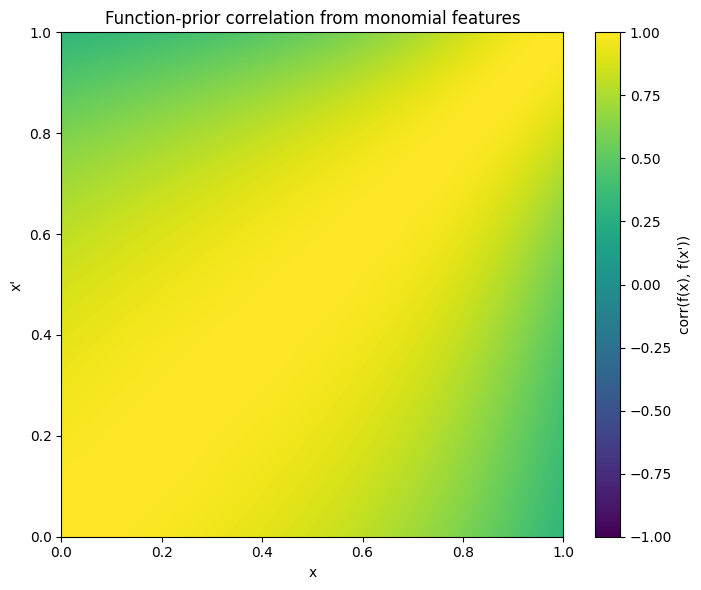

In [10]:
# Visualise the covariance function induced by the raw monomial prior.
Phi_prior_grid = models.polynomial_features(x_prior_grid, degree=prior_degree)
prior_covariance = small_tau**2 * (Phi_prior_grid @ Phi_prior_grid.T)
prior_correlation = prior_covariance / np.sqrt(np.outer(np.diag(prior_covariance), np.diag(prior_covariance)))

fig, ax = plt.subplots(figsize=(7.2, 6.0))
image = ax.imshow(
    prior_correlation,
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    aspect="auto",
    cmap="viridis",
    vmin=-1.0,
    vmax=1.0,
)
ax.set_title("Function-prior correlation from monomial features")
ax.set_xlabel("x")
ax.set_ylabel("x'")
fig.colorbar(image, ax=ax, label="corr(f(x), f(x'))")
fig.tight_layout()
show_fig(fig)


**Inspect and repack**

- Inspect: compare the sampled functions with the covariance heatmap. Which parts of the input range tend to move together under this prior?
- Repack: state the prior as a belief over curves, not only as a distribution over coefficients.

**Diagnose**

The prior is visible in function space. Small parameter scales produce calmer prior samples. Larger scales permit more volatile curves before any data are observed.

The observed-$x$ rug marks are a reminder from the data-space notebooks: prior behaviour between or beyond measurements is not evidence-constrained yet. It is a modelling commitment.

The covariance heatmap shows the same idea without sampling. Inputs with high prior correlation tend to move together across sampled functions. Because this covariance came from raw monomial features, it also reveals a property of that parameterisation.

Connect this back to regularisation. A penalty on parameter size can be read as prior belief about which $\theta$ values were plausible before $\mathcal{D}$. The scientific question is whether the induced prior over functions matches the behaviour you would have expected before measuring anything.


## MAP and Ridge From a Balance Question

Suppose the residuals are being judged under an instrument precision $\sigma$, and the prior says non-intercept coefficients typically have scale $\tau$. Which $\theta\in\Theta$ best balances two pressures: explain $\mathcal{D}$ under the measurement story, and stay in a plausible region of parameter space?

The posterior density answers that question. Its highest-density point is the maximum a posteriori estimate, or MAP.

With Gaussian measurement noise,

$$
p(\mathcal{D}\mid\theta,\sigma) \propto
\exp\left(-\frac{1}{2\sigma^2}\lVert\Phi\theta-y\rVert_2^2\right),
$$

and a Gaussian prior on the penalised parameters,

$$
p(\theta\mid\tau) \propto
\exp\left(-\frac{1}{2\tau^2}\lVert R\theta\rVert_2^2\right),
$$

the negative log posterior is proportional to

$$
\frac{1}{\sigma^2}\lVert\Phi\theta-y\rVert_2^2
+\frac{1}{\tau^2}\lVert R\theta\rVert_2^2.
$$

For the ridge convention from Notebook 03, $R=\operatorname{diag}(0,1,\ldots,1)$, so the intercept is unpenalised. Multiplying by $\sigma^2$ gives

$$
\lVert\Phi\theta-y\rVert_2^2 + \lambda\lVert R\theta\rVert_2^2,
\qquad \lambda=\frac{\sigma^2}{\tau^2}.
$$

This is extension-depth notation for a familiar selector. The likelihood term is the residual pressure, the prior term is the coefficient-pressure, and the MAP estimate is the selected $s$ under this probabilistic $\mathcal{O}$.

Change `map_sigma` or `map_tau` and predict which pressure should dominate before rerunning the cell.


In [11]:
# Compare the ridge solution with the MAP formula.
map_degree = 9
map_sigma = 0.20
map_tau = 0.30
map_lambda = (map_sigma**2) / (map_tau**2)

Phi_map = models.polynomial_features(x_like_train, degree=map_degree)
R = np.eye(map_degree + 1)
R[0, 0] = 0.0

map_system = Phi_map.T @ Phi_map + map_lambda * R
map_rhs = Phi_map.T @ y_like_train
map_coeffs = np.linalg.solve(map_system, map_rhs)
ridge_coeffs = models.fit_polynomial_ridge_map(
    x_like_train,
    y_like_train,
    degree=map_degree,
    lambda_reg=map_lambda,
)

print_rows(
    [
        {"quantity": "sigma", "value": map_sigma},
        {"quantity": "tau", "value": map_tau},
        {"quantity": "lambda = sigma^2 / tau^2", "value": map_lambda},
        {"quantity": "max_abs_difference", "value": np.max(np.abs(map_coeffs - ridge_coeffs))},
    ],
    digits=6,
    title="Ridge as a MAP estimate",
)

Ridge as a MAP estimate
01. quantity=sigma, value=0.200000
02. quantity=tau, value=0.300000
03. quantity=lambda = sigma^2 / tau^2, value=0.444444
04. quantity=max_abs_difference, value=0


**Inspect and repack**

- Inspect: the `max_abs_difference` should be near numerical precision. That checks whether the MAP formula and ridge helper selected the same coefficients for this `lambda`.
- Repack: explain `map_lambda = sigma^2 / tau^2` as the balance between measurement tolerance and prior shrinkage.

## Posterior Uncertainty: Where Has Data Constrained the Function?

A MAP estimate gives one $\theta$. The posterior distribution keeps the remaining uncertainty over $\theta$ after conditioning on the chosen degree, feature map, noise scale, prior scale, intercept convention, and $\mathcal{D}$.

For the ridge convention with unpenalised intercept, define the prior precision selector

$$
P_0=\operatorname{diag}(0,1,1,\ldots,1).
$$

The posterior covariance and mean are

$$
\Sigma_N = \left(\sigma^{-2}\Phi^\top\Phi + \tau^{-2}P_0\right)^{-1},
\qquad
\mu_N = \sigma^{-2}\Sigma_N\Phi^\top y.
$$

For new inputs with feature matrix $\Phi_*$,

$$
\operatorname{cov}(f_*\mid\mathcal{D}) = \Phi_*\Sigma_N\Phi_*^\top.
$$

For a single new input $x_*$,

$$
\operatorname{var}(f_*\mid\mathcal{D})
= \phi(x_*)^\top\Sigma_N\phi(x_*).
$$

For a future noisy observation, add $\sigma^2$.

**Predict before running:** where should the latent uncertainty band be widest: near observed inputs, between observed inputs, or at the edges? Change one of `uncertainty_tau`, `uncertainty_sigma`, or the probe locations at a time, then rerun both posterior cells below.

The plot asks where the data and prior have pinned down the latent function, and where several functions are still plausible.


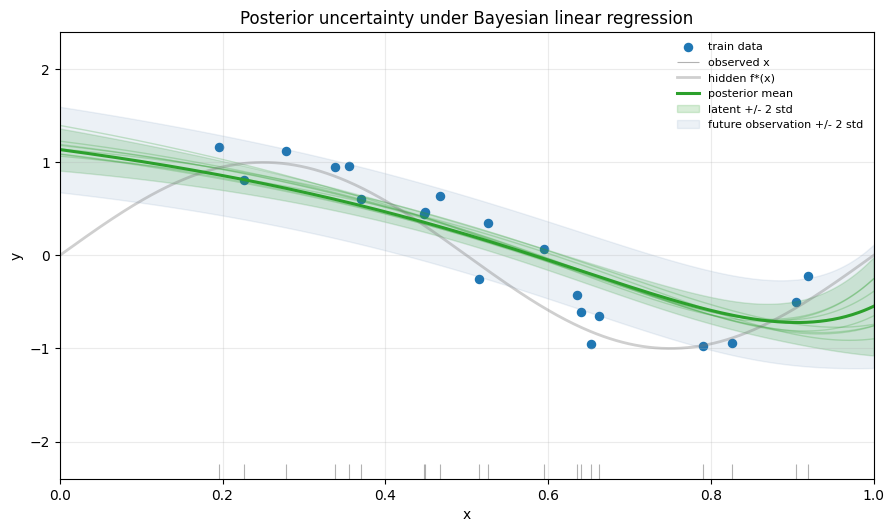

In [12]:
# Visualise posterior uncertainty for the latent function.
uncertainty_degree = 9
uncertainty_sigma = 0.20
uncertainty_tau = 0.30
posterior_sample_seed = 44

Phi_train = models.polynomial_features(x_like_train, degree=uncertainty_degree)
Phi_grid = models.polynomial_features(x_grid, degree=uncertainty_degree)
prior_precision = np.zeros((uncertainty_degree + 1, uncertainty_degree + 1))
prior_precision[1:, 1:] = np.eye(uncertainty_degree)
posterior_precision = (Phi_train.T @ Phi_train) / uncertainty_sigma**2 + prior_precision / uncertainty_tau**2
posterior_cov = np.linalg.inv(posterior_precision)
posterior_mean = (posterior_cov @ Phi_train.T @ y_like_train) / uncertainty_sigma**2

latent_mean = Phi_grid @ posterior_mean
latent_cov = Phi_grid @ posterior_cov @ Phi_grid.T
latent_var = np.diag(latent_cov)
latent_std = np.sqrt(np.maximum(latent_var, 0.0))
obs_std = np.sqrt(latent_var + uncertainty_sigma**2)

rng = np.random.default_rng(posterior_sample_seed)
posterior_theta_samples = rng.multivariate_normal(
    mean=posterior_mean,
    cov=posterior_cov,
    size=8,
    method="svd",
)
posterior_function_samples = posterior_theta_samples @ Phi_grid.T

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for sample in posterior_function_samples:
    ax.plot(x_grid, sample, color="#2ca02c", alpha=0.25, linewidth=1.0)
ax.scatter(x_like_train, y_like_train, s=34, color="#1f77b4", label="train data")
ax.vlines(x_like_train, -2.4, -2.24, color="#222222", alpha=0.35, linewidth=0.8, label="observed x")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax.plot(x_grid, latent_mean, color="#2ca02c", linewidth=2.2, label="posterior mean")
ax.fill_between(x_grid, latent_mean - 2 * latent_std, latent_mean + 2 * latent_std, color="#2ca02c", alpha=0.18, label="latent +/- 2 std")
ax.fill_between(x_grid, latent_mean - 2 * obs_std, latent_mean + 2 * obs_std, color="#4c78a8", alpha=0.10, label="future observation +/- 2 std")
ax.set_title("Posterior uncertainty under Bayesian linear regression")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.4, 2.4)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


In [13]:
# Probe posterior uncertainty at a few input locations.
probe_x = np.array([0.05, 0.20, 0.50, 0.80, 0.95])
Phi_probe = models.polynomial_features(probe_x, degree=uncertainty_degree)
probe_latent_var = np.diag(Phi_probe @ posterior_cov @ Phi_probe.T)
probe_latent_std = np.sqrt(np.maximum(probe_latent_var, 0.0))
probe_obs_std = np.sqrt(probe_latent_var + uncertainty_sigma**2)
nearest_train_distance = np.min(np.abs(probe_x[:, None] - x_like_train[None, :]), axis=1)

probe_rows = []
for x_value, distance, latent_std_value, obs_std_value in zip(
    probe_x,
    nearest_train_distance,
    probe_latent_std,
    probe_obs_std,
):
    probe_rows.append(
        {
            "x_probe": x_value,
            "nearest_train_distance": distance,
            "latent_std": latent_std_value,
            "future_observation_std": obs_std_value,
        }
    )

print_rows(probe_rows, digits=4, title="Posterior uncertainty probes")

Posterior uncertainty probes
01. x_probe=0.0500, nearest_train_distance=0.1454, latent_std=0.1037, future_observation_std=0.2253
02. x_probe=0.2000, nearest_train_distance=0.0046, latent_std=0.0781, future_observation_std=0.2147
03. x_probe=0.5000, nearest_train_distance=0.0152, latent_std=0.0506, future_observation_std=0.2063
04. x_probe=0.8000, nearest_train_distance=0.0095, latent_std=0.0717, future_observation_std=0.2125
05. x_probe=0.9500, nearest_train_distance=0.0301, latent_std=0.1664, future_observation_std=0.2602


**Inspect and repack**

- Inspect: compare the widest latent band with the largest `latent_std` rows. Are they near sparse data locations, near the edges, or both?
- Repack: say "uncertainty under this model and these assumptions," not simply "the uncertainty."

The uncertainty band and the probe table reflect the assumptions we chose: polynomial features, Gaussian noise, Gaussian prior scale, the intercept convention, and the observed data locations. They are conditional uncertainty inside this model. They leave open uncertainty over the feature map, polynomial degree, noise scale, prior scale, and whether the observation story is scientifically adequate.

In workshop-frame language, $\mathcal{H}$ is the polynomial feature map and degree, $\mathcal{D}$ is the finite observed sample, and $\mathcal{O}$ is the likelihood-prior-posterior machinery. The posterior predictive summary is not a universal uncertainty statement; it is the selected probabilistic summary inside those choices.

The posterior parameter samples give the same message in function space. With a proper Gaussian prior over all parameters, a finite-feature Bayesian linear model is also the parameter-space view of a Gaussian process with kernel $k(x,x')=\phi(x)^\top\Sigma_0\phi(x')$. The unpenalised-intercept convention we used for MAP is a useful modelling choice; evidence calculations and kernel priors need a proper prior or an explicit limiting argument.


## Final Diagnostic Frame

When a fitted model behaves strangely, use the behaviour as a clue. Each symptom points back to an interaction among the hypothesis space, the dataset, the measurement story, prior assumptions, and the optimization space.

- Hypothesis space $\mathcal{H}$: what hypotheses $h_\theta$ were possible?
- Parameter space $\Theta$: which parameter values $\theta$ could select those hypotheses?
- Dataset $\mathcal{D}$: what evidence constrained those possibilities?
- Optimization space $\mathcal{O}$: what likelihood or loss, prior or penalty, evidence calculation, optimizer, and summary rule selected or summarised the result?

Underfitting, overfitting, edge extrapolation, excessive smoothness, and overconfident uncertainty can have different causes. The useful move is to turn the behaviour into a question you can inspect: which assumption would need to change for this outcome to become unsurprising?

**Probabilistic glossary**

| Term | Short meaning in this notebook |
|---|---|
| Likelihood | Compatibility of $\mathcal{D}$ with a proposed $\theta$ under a measurement story |
| Prior | Probability statement before seeing this dataset, over parameters, functions, or model classes |
| Posterior | Updated probability after combining likelihood and prior |
| Evidence | Prior predictive probability of the data under a model class |
| MAP | Posterior mode; the single parameter value selected by likelihood-plus-prior balance |
| Prior predictive | Distribution over possible data or functions before conditioning on $\mathcal{D}$ |
| Posterior predictive | Distribution over latent functions or future observations after conditioning on $\mathcal{D}$ |

Final check: which conclusion in this notebook depends most on the measurement story, which depends most on the prior, and which depends most on the observed data locations?


## Bridge to Later Workshops

Workshop 1 used a deliberately friendly case:

$$
h_\theta(x)=\theta^\top\phi(x), \qquad \theta\in\Theta, \qquad h_\theta\in\mathcal{H}.
$$

The human chose the feature map. The optimizer chose only $\theta$. Because the model is linear in those parameters, least squares, ridge, and Bayesian linear regression had direct formulas.

Later workshops can relax both conveniences. Neural networks learn parts of the feature map, so the hypothesis space includes learned representations. The objective is usually shaped by iterative optimisation. The dataset may be high dimensional, biased, incomplete, or expensive to label. Probabilistic assumptions may be approximate, implicit, or replaced by other uncertainty diagnostics.

The diagnostic habit still holds:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow \text{model behaviour}.
$$

As the machinery gets richer, keep asking the same questions: what hypotheses were possible, what evidence was available, what optimization space selected or summarised the model, and what would make the resulting behaviour defensible for the task?


## References

A compact set of checked references for likelihood, Bayesian linear regression, evidence, Bayes factors, and Gaussian-process connections.

- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Gaussian likelihoods, MAP estimation, Bayesian linear regression, and predictive uncertainty.
- Lindley, D. V., & Smith, A. F. M. (1972). [*Bayes Estimates for the Linear Model*](https://academic.oup.com/jrsssb/issue/34/1), *Journal of the Royal Statistical Society: Series B*, 34(1), 1-18. Classical Bayesian linear-model conjugacy and shrinkage.
- MacKay, D. J. C. (1992). [*Bayesian Interpolation*](https://direct.mit.edu/neco/article/4/3/415/5639/Bayesian-Interpolation), *Neural Computation*, 4(3), 415-447. Model evidence, Occam factors, prior scale, and Bayesian interpolation.
- Kass, R. E., & Raftery, A. E. (1995). [*Bayes Factors*](https://www.tandfonline.com/doi/abs/10.1080/01621459.1995.10476572), *Journal of the American Statistical Association*, 90(430), 773-795. Bayesian model comparison and the interpretation of evidence.
- Rasmussen, C. E., & Williams, C. K. I. (2006). [*Gaussian Processes for Machine Learning*](https://mitpress.mit.edu/9780262182539/gaussian-processes-for-machine-learning/). Relationship between Bayesian linear models, kernels, Gaussian processes, and function-space uncertainty.
